In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score

In [2]:
data = 'Dataset/Housing.csv'
df = pd.read_csv(data)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Original Features : 13
Polynomial Features : 2379
LINEAR REGRESSION
Training R2 : 0.994
Testing R2 : -1.1946104833230355e+20
RIDGE
Training R2 : 0.9637
Testing R2 : 0.2892


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.247e+12, tolerance: 1.344e+11
  model = cd_fast.enet_coordinate_descent(


LASSO
Training R2 : 0.9922
Testing R2 : -13.4971


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.238e+13, tolerance: 1.344e+11
  model = cd_fast.enet_coordinate_descent(


ELASTIC NET
Training R2 : 0.9786
Testing R2 : 0.0068
               Model  Train R2       Test R2
0  Linear Regression  0.994023 -1.194610e+20
1              Ridge  0.963736  2.891560e-01
2              Lasso  0.992212 -1.349715e+01
3        Elastic Net  0.978595  6.844755e-03


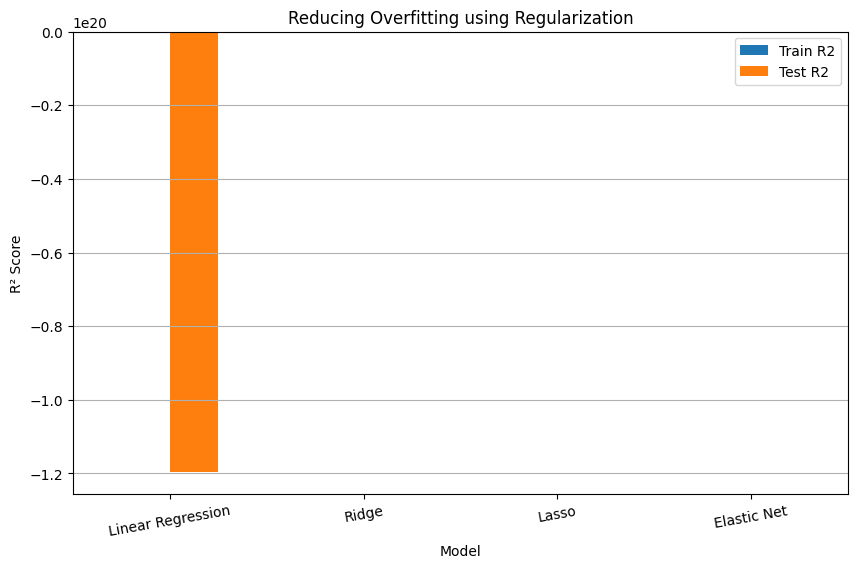

               Model  Train R2       Test R2    Difference
0  Linear Regression  0.994023 -1.194610e+20  1.194610e+20
1              Ridge  0.963736  2.891560e-01  6.745803e-01
2              Lasso  0.992212 -1.349715e+01  1.448936e+01
3        Elastic Net  0.978595  6.844755e-03  9.717506e-01


In [3]:
df = pd.get_dummies(df, drop_first=True)

df.head()


# In[5]:


X = df.drop("price", axis=1)
y = df["price"]


# In[6]:


X_train,X_test,y_train,y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)


# In[7]:


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# In[80]:


poly = PolynomialFeatures(
    degree=4,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print("Original Features :", X_train.shape[1])
print("Polynomial Features :", X_train_poly.shape[1])


# In[81]:


linear = LinearRegression()

linear.fit(X_train_poly, y_train)

train_pred = linear.predict(X_train_poly)
test_pred = linear.predict(X_test_poly)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("LINEAR REGRESSION")
print("Training R2 :", round(train_r2,4))
print("Testing R2 :", round(test_r2,4))


# In[83]:


ridge = Ridge(alpha=100)

ridge.fit(X_train_poly, y_train)

train_pred = ridge.predict(X_train_poly)
test_pred = ridge.predict(X_test_poly)

ridge_train = r2_score(y_train, train_pred)
ridge_test = r2_score(y_test, test_pred)

print("RIDGE")
print("Training R2 :", round(ridge_train,4))
print("Testing R2 :", round(ridge_test,4))


# In[ ]:


lasso = Lasso(
    alpha=0.1,
    max_iter=50000
)

lasso.fit(X_train_poly, y_train)

train_pred = lasso.predict(X_train_poly)
test_pred = lasso.predict(X_test_poly)

lasso_train = r2_score(y_train, train_pred)
lasso_test = r2_score(y_test, test_pred)

print("LASSO")
print("Training R2 :", round(lasso_train,4))
print("Testing R2 :", round(lasso_test,4))


# In[77]:


elastic = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    max_iter=50000
)

elastic.fit(X_train_poly, y_train)

train_pred = elastic.predict(X_train_poly)
test_pred = elastic.predict(X_test_poly)

elastic_train = r2_score(y_train, train_pred)
elastic_test = r2_score(y_test, test_pred)

print("ELASTIC NET")
print("Training R2 :", round(elastic_train,4))
print("Testing R2 :", round(elastic_test,4))


# In[78]:


comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Elastic Net"
    ],

    "Train R2":[
        train_r2,
        ridge_train,
        lasso_train,
        elastic_train
    ],

    "Test R2":[
        test_r2,
        ridge_test,
        lasso_test,
        elastic_test
    ]
})

print(comparison)


# In[79]:





# In[62]:


comparison["Difference"] = comparison["Train R2"] - comparison["Test R2"]

print(comparison)


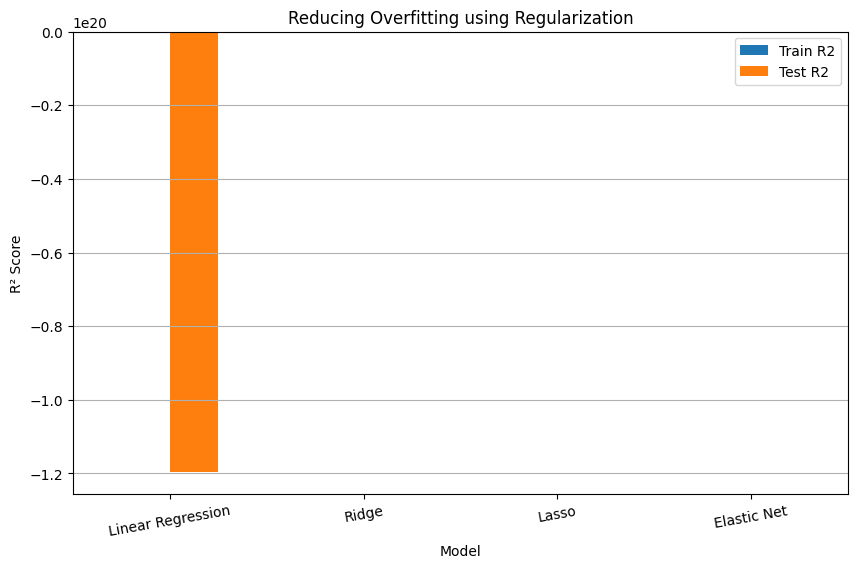

In [4]:
comparison.plot(
    x="Model",
    y=["Train R2", "Test R2"],
    kind="bar",
    figsize=(10,6)
)

plt.title("Reducing Overfitting using Regularization")
plt.ylabel("R² Score")
plt.xticks(rotation=10)
plt.grid(axis="y")
plt.show()